### HW Set #2
Group Members' Names and Student IDs

1) Syed Zaim Naqvi (65443590)
2) Jasper Yang (19469535)
3) Yashas Ganesh Prasad (44773950)
4) Xuanfu Zhu (77225654)
5) Taha Memon (40222937)

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

**1) Indexing (20 marks)**
1) read GDP data from "https://raw.githubusercontent.com/datasets/gdp/master/data/gdp.csv"
2) rename the appropriate column to "GDP"
3) have data only for 2 countries of your choice and from 2020 onwards only using booliean filtering
5) set both country and year as index for the original datafram (not the selection ones)
6) repeat 3 using exactly for 2020 and 2023
7) repeat 3 but for 3 countries of your choice and from 2020 to 2023 (range). Hint use pd.IndexSlice

In [2]:
#part 1
import pandas as pd
gdp = pd.read_csv("https://raw.githubusercontent.com/datasets/gdp/master/data/gdp.csv")
print(gdp.head())
#this involves reading a csv format file from a github site on the GDP of various countries using a pandas method pd.read_csv
#the print(gdp.head()) helps us see the first five rows of the gdp dataset.

  Country Name Country Code  Year         Value
0  Afghanistan          AFG  2000  3.521418e+09
1  Afghanistan          AFG  2001  2.813572e+09
2  Afghanistan          AFG  2002  3.825701e+09
3  Afghanistan          AFG  2003  4.520947e+09
4  Afghanistan          AFG  2004  5.224897e+09


In [3]:
#part 2
gdp
gdp = gdp.rename(columns = {"Value":"GDP"}) 
gdp
#this involves using the rename method to change the column name from "Value" to "Column" in the gdp dataset

,Country Name,Country Code,Year,GDP
0,Afghanistan,AFG,2000,3.521418e+09
1,Afghanistan,AFG,2001,2.813572e+09
2,Afghanistan,AFG,2002,3.825701e+09
3,Afghanistan,AFG,2003,4.520947e+09
4,Afghanistan,AFG,2004,5.224897e+09
...,...,...,...,...
13974,Zimbabwe,ZWE,2019,2.183223e+10
13975,Zimbabwe,ZWE,2020,2.150970e+10
13976,Zimbabwe,ZWE,2021,2.837124e+10
13977,Zimbabwe,ZWE,2022,2.736663e+10


In [4]:
#part 3
gdp
part3gdp = gdp[(gdp["Country Name"].isin(["Canada","Australia"])) & (gdp["Year"] >= 2020)]
part3gdp
#this involves using a boolean type filtering for obtaining data for Canada and Australia only, from 2020 onwards.
#the ... (gdp["Country Name"].isin(["Canada","Australia"])) & (gdp["Year"] >= 2020)
    #this will return true or false for every value if it meets the two conditions:
        #country name having Canada or Australia
        #year being 2020 or greater
#the & sign makes sure that both conditions are met for the output to be true.

,Country Name,Country Code,Year,GDP
639,Australia,AUS,2020,1.330382e+12
640,Australia,AUS,2021,1.559034e+12
641,Australia,AUS,2022,1.692957e+12
642,Australia,AUS,2023,1.723827e+12
1972,Canada,CAN,2020,1.655685e+12
1973,Canada,CAN,2021,2.007472e+12
1974,Canada,CAN,2022,2.161483e+12
1975,Canada,CAN,2023,2.140086e+12


In [5]:
#part 4
part4gdp = gdp.set_index(["Country Name", "Year"])
part4gdp
#this involves setting multiple indexes to the original gdp data using the set_index method
#the result of the code also creates a hierarchal index:
    #with Country Name being in position 1, whereas Year being in position 2

Country Code           GDP
Country Name Year                           
Afghanistan  2000          AFG  3.521418e+09
             2001          AFG  2.813572e+09
             2002          AFG  3.825701e+09
             2003          AFG  4.520947e+09
             2004          AFG  5.224897e+09
...                        ...           ...
Zimbabwe     2019          ZWE  2.183223e+10
             2020          ZWE  2.150970e+10
             2021          ZWE  2.837124e+10
             2022          ZWE  2.736663e+10
             2023          ZWE  2.653827e+10

[13979 rows x 2 columns]

In [6]:
#part 5
part5gdp = part4gdp.loc[(["Australia","Canada"], [2020,2023]),:]
part5gdp
# Since we have to use filtering similar to part 3, 
    #we would now have to use the .loc method instead of using boolean filtering 
    #as the .isin method used in part 3 wouldn't work here, due to the columns being indexed.
# since we want specific countries and years
    #we can use the .isin method to obtain the rows that contain those specific values

Country Code           GDP
Country Name Year                           
Australia    2020          AUS  1.330382e+12
             2023          AUS  1.723827e+12
Canada       2020          CAN  1.655685e+12
             2023          CAN  2.140086e+12

In [7]:
#part 6
import pandas as pd
part6gdp = part4gdp.loc[pd.IndexSlice[["Australia","Canada","India"], 2020:2023], :]

#since question provides hint to use pd.IndexSlice, assuming have to use multi-indexed data from part 4
#this involves using IndexSlice for multi-index filtering.

In [8]:
gdp.dtypes

Country Name     object
Country Code     object
Year              int64
GDP             float64
dtype: object

***2) Cleaning Data and Groupby (20 marks)***

1. read titanic data from https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
2. check the number of missing values for the columns
3. fill missing Age values with median age and Fill missing Embarked with the most frequent port (note need to use mode()[0] as mode()
   -returns a series) and drop cabin column
4. calculate average age of passengers by Pclass (1st, 2nd, 3rd class) and round to 2 decimal points
5. calculate survival rate by Sex

In [9]:
url_t = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
titan = pd.read_csv(url_t) #load in data 
titan.head() # display first 5 rows

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [10]:
titan.isna().sum() #find the number of NaN values in each column

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [11]:
titan["Age"] = titan["Age"].fillna(value = titan["Age"].median()) #fill NaN in Age column will median value

titan["Embarked"] = titan["Embarked"].fillna(value = titan["Embarked"].mode()[0]) #fill NaN in Embarked column with most frequent value

titan = titan.drop(columns = ["Cabin"]) #drop Cabin column 

titan[["Age","Embarked"]].isna().sum() #Check to see if NaN's were filled

Age         0
Embarked    0
dtype: int64

In [12]:
titan_class = titan.groupby("Pclass")[["Age"]].mean().round(2).rename(columns = {"Age":"Mean_Age"}) #Grouped by PClass 
# and averaged the age column, rounded to 2 decimal points and renamed column to Mean_Age

titan_class

,Mean_Age
Pclass,
1,36.81
2,29.77
3,25.93


In [13]:
titan_survival = (titan.groupby("Sex")[["Survived"]].mean()*100).rename(columns = {"Survived":"Survival_rate"})
#grouped by Sex and averaged Survived dummy and multiplied by 100 to get percentage points, renamed column to Survival_rate
titan_survival

,Survival_rate
Sex,
female,74.203822
male,18.890815


***3) Seaborn Plot (20 marks)***: ZAIM

1) download `tips` data from seaborn
2) draw a plot with spliting the data based on `time` and `smoking status`. Use `sex` for color and `size` for size
3) for the above `titanic data`, plot a histogram of `Age` for survived vs not survived passengers (use `hue`). Also add `kde` (kernal density estimate) or probability density. you may stack the two histograms.

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [15]:
#load Seaborn's built-in example dataset
tips = sns.load_dataset("tips")
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


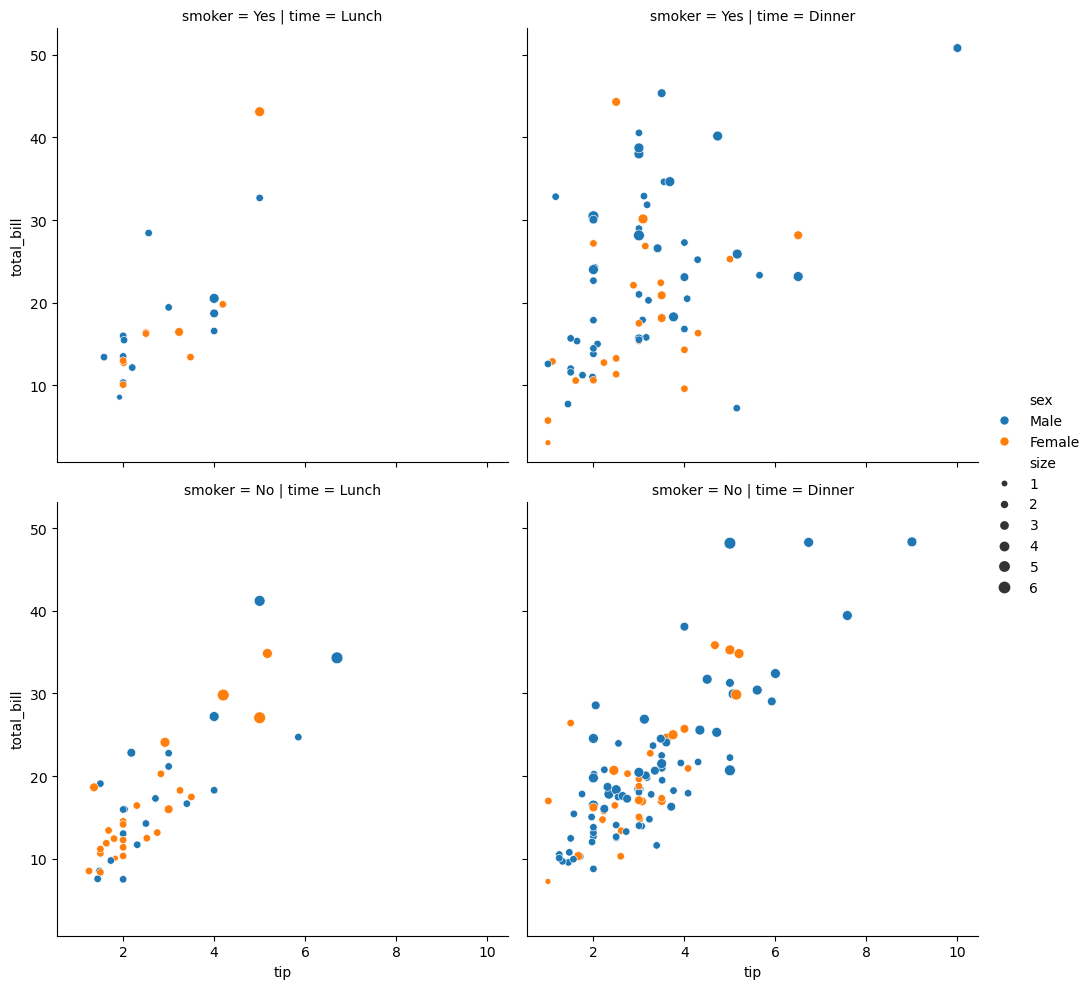

In [16]:
#create a scatterplot (default) to show relation of x = tips and y = total bill, split via time (Lunch or Dinner) using columns and 
#for smoker status (yes or no) using row. The color of datapoints depends on sex and size of points is given by size column in data set
sns.relplot(data = tips, x = 'tip', y = 'total_bill', col = 'time', row = 'smoker', hue = 'sex', size = 'size')
plt.show()

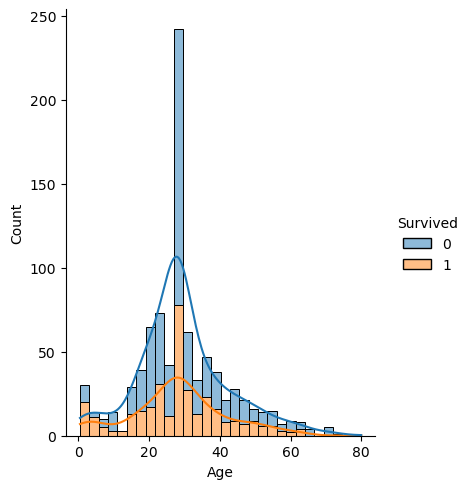

In [17]:
#create two histograms stacked on top of each other (with a probability density curve on top with area = 1 for trend) 
#for numerical variable age depending on if individual survived or not for each histogram stacked.
sns.displot(data = titan, x = 'Age', hue='Survived', multiple ='stack', kde = True, aspect =0.8)
plt.show()

**4) Merge (20 marks)**
1) read GDP data from "https://raw.githubusercontent.com/datasets/gdp/master/data/gdp.csv"
2) read population data from "https://raw.githubusercontent.com/datasets/population/master/data/population.csv"
3) change "Year" from both data to numeric value.
4) rename the columns as appropriate.
5) have population data only for 2020 onwards
6) inner merge these two data with apprpriate common ids 

In [18]:
#part 1
import pandas as pd

gdp = pd.read_csv("https://raw.githubusercontent.com/datasets/gdp/master/data/gdp.csv")
print(gdp.head())

#this reads the GDP dataset from the github link using pandas
#gdp.head() shows the first few rows so we can see what the dataset looks like

  Country Name Country Code  Year         Value
0  Afghanistan          AFG  2000  3.521418e+09
1  Afghanistan          AFG  2001  2.813572e+09
2  Afghanistan          AFG  2002  3.825701e+09
3  Afghanistan          AFG  2003  4.520947e+09
4  Afghanistan          AFG  2004  5.224897e+09


In [19]:
#part 2
pop = pd.read_csv("https://raw.githubusercontent.com/datasets/population/master/data/population.csv")
print(pop.head())

#this loads the population dataset in the same way
#head() again lets us quickly check the data and column names

  Country Name Country Code  Year  Value
0        Aruba          ABW  1960  54922
1        Aruba          ABW  1961  55578
2        Aruba          ABW  1962  56320
3        Aruba          ABW  1963  57002
4        Aruba          ABW  1964  57619


In [20]:
#part 3
gdp["Year"] = pd.to_numeric(gdp["Year"])
pop["Year"] = pd.to_numeric(pop["Year"])

#this converts the Year column into numeric values
#this makes it easier to filter or compare years later

In [21]:
#part 4
gdp = gdp.rename(columns={"Value": "GDP"})
pop = pop.rename(columns={"Value": "Population"})

#both datasets had a column called "Value"
#so we rename them to GDP and Population to avoid confusion

In [22]:
#part 5
pop_2020 = pop[pop["Year"] >= 2020]
print(pop_2020.head())

#this keeps only the population data from 2020 onwards
#the condition inside the brackets filters the rows

   Country Name Country Code  Year  Population
60        Aruba          ABW  2020      108587
61        Aruba          ABW  2021      107700
62        Aruba          ABW  2022      107310
63        Aruba          ABW  2023      107359
64        Aruba          ABW  2024      107995


In [23]:
#part 6
merged = pd.merge(gdp, pop_2020,
                  on=["Country Name","Country Code","Year"],
                  how="inner")
print(merged.head())

#this merges the GDP and population datasets together
#we match rows using country name, country code, and year
#inner merge keeps only rows that appear in both datasets

                  Country Name Country Code  Year           GDP  Population
0                  Afghanistan          AFG  2020  1.995593e+10    39068979
1                  Afghanistan          AFG  2021  1.426650e+10    40000412
2                  Afghanistan          AFG  2022  1.450216e+10    40578842
3  Africa Eastern and Southern          AFE  2020  9.290741e+11   694446100
4  Africa Eastern and Southern          AFE  2021  1.086772e+12   713090928


***5) Time Series (20 marks)***

1) install yfinance (pip install yfinance) and then import
2) download the data as: df = yf.download("AAPL", start="2021-01-01", end="2023-12-31")
3) use df_aapl['Close'].plot() to plot time series. Give a suitable title and ylabel
4) plot 7 day and 30 day moving averages of `close` value and plot. Add title, xlabel, ylabel and legend

In [24]:
%pip install yfinance
#this installs the yfinance package, which allows us to download stock market data directly from Yahoo Finance

Note: you may need to restart the kernel to use updated packages.


In [25]:
import yfinance as yf

#download Apple stock data from 2021-01-01 to 2023-12-31
df_aapl = yf.download("AAPL", start="2021-01-01", end="2023-12-31")
print(df_aapl.head())

#this imports the yfinance library and downloads Apple (AAPL) stock data
#the data includes prices such as Open, High, Low, Close, and Volume
#head() shows the first few rows so we can see the structure of the dataset

[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
Date                                                                 
2021-01-04  125.856697  129.941372  123.279459  129.853846  143301900
2021-01-05  127.412758  128.122724  124.903597  125.350973   97664900
2021-01-06  123.123848  127.451665  122.909887  124.213098  155088000
2021-01-07  127.325256  128.015768  124.349279  124.835550  109578200
2021-01-08  128.424225  128.988301  126.654191  128.793781  105158200


<Figure size 1000x500 with 0 Axes>

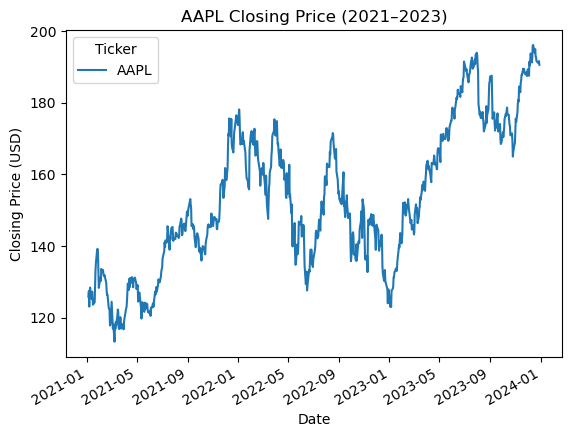

In [26]:
#plot the daily closing price of Apple stock over time
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

df_aapl['Close'].plot()

plt.title("AAPL Closing Price (2021–2023)")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")

plt.show()

#matplotlib is imported to create visualizations
#figure() sets the size of the plot
#df_aapl['Close'].plot() plots the daily closing price of Apple stock over time
#these lines add labels and a title to make the graph easier to read
#xlabel shows the dates on the x-axis, while ylabel shows the closing price in USD on the y-axis
#show() displays the completed plot

In [27]:
#calculate the 7-day and 30-day moving averages of the closing price
#moving averages help smooth short-term fluctuations in stock prices
df_aapl['MA7'] = df_aapl[('Close','AAPL')].rolling(window=7).mean()
df_aapl['MA30'] = df_aapl[('Close','AAPL')].rolling(window=30).mean()

#rolling(window=7) calculates the average closing price over the previous 7 days
#rolling(window=30) calculates the average over the previous 30 days
#these are stored as new columns called MA7 and MA30 in the dataframe

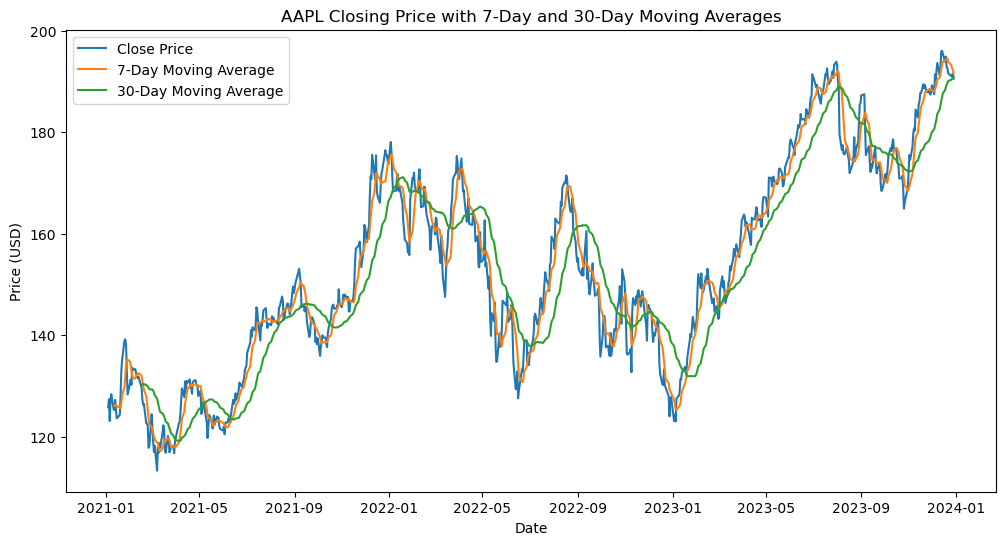

In [28]:
#plot the closing price together with the 7-day and 30-day moving averages

plt.figure(figsize=(12,6))

plt.plot(df_aapl.index, df_aapl[('Close','AAPL')], label='Close Price')
plt.plot(df_aapl.index, df_aapl['MA7'], label='7-Day Moving Average')
plt.plot(df_aapl.index, df_aapl['MA30'], label='30-Day Moving Average')

plt.title("AAPL Closing Price with 7-Day and 30-Day Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()

plt.show()

#this graph shows the original closing price together with the two moving averages
#the moving averages make trends easier to see by smoothing daily fluctuations
#legend() adds labels so we can distinguish the three lines on the graph

In [29]:
#check the columns
df_aapl.columns

#this shows all column names in the dataframe
#it helps verify what variables are available after downloading the data and creating the moving averages

MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL'),
            (   'MA7',     ''),
            (  'MA30',     '')],
           names=['Price', 'Ticker'])